# Stage 0: Data Inspection and Cleaning
This notebook loads, inspects, cleans, and profiles the NVDA dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# Ensure output directories exist
os.makedirs('../data/processed', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')


## 1. Load Data


In [2]:
def load_and_clean(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    return df

file_path = '../data/raw/NVDA_raw.csv'
df = load_and_clean(file_path)
df.head()


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2005-01-03,0.180148,0.196500,0.206000,0.195667,0.203167,1066716000
2005-01-04,0.171668,0.187250,0.198250,0.184250,0.197917,790224000
2005-01-05,0.173272,0.189000,0.191250,0.184250,0.185250,724812000
2005-01-06,0.171592,0.187167,0.194583,0.185833,0.192333,563568000
2005-01-07,0.168306,0.183583,0.189000,0.180833,0.187583,763092000


## 2. Compute returns and dollar volume


In [3]:
def compute_dollar_volume(df):
    return df['Adj Close'] * df['Volume']

df['log_return'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))
df['dollar_volume'] = compute_dollar_volume(df)
df.dropna(inplace=True)
df.head()


,Adj Close,Close,High,Low,Open,Volume,log_return,dollar_volume
Date,,,,,,,,
2005-01-04,0.171668,0.187250,0.198250,0.184250,0.197917,790224000,-0.048218,1.356562e+08
2005-01-05,0.173272,0.189000,0.191250,0.184250,0.185250,724812000,0.009302,1.255898e+08
2005-01-06,0.171592,0.187167,0.194583,0.185833,0.192333,563568000,-0.009745,9.670370e+07
2005-01-07,0.168306,0.183583,0.189000,0.180833,0.187583,763092000,-0.019335,1.284330e+08
2005-01-10,0.168688,0.184000,0.185833,0.182917,0.184167,579552000,0.002269,9.776370e+07


## 3. Basic Statistics and Validation


In [4]:
print(f"Shape: {df.shape}")
print(f"Date Range: {df.index.min()} to {df.index.max()}")
print(f"Missing Values:\n{df.isnull().sum()}")
print("\nBasic Statistics:")
display(df.describe())

# Validation checks
assert df.isnull().sum().sum() == 0, "NaN values found!"
assert df.index.is_monotonic_increasing, "Dates are not monotonic!"
assert (df[['Adj Close', 'Close', 'High', 'Low', 'Open']] > 0).all().all(), "Prices must be > 0"
assert (df['Volume'] > 0).all(), "Volume must be > 0"


Shape: (5113, 8)
Date Range: 2005-01-04 00:00:00 to 2025-04-30 00:00:00
Missing Values:
Adj Close        0
Close            0
High             0
Low              0
Open             0
Volume           0
log_return       0
dollar_volume    0
dtype: int64

Basic Statistics:


,Adj Close,Close,High,Low,Open,Volume,log_return,dollar_volume
count,5113.000000,5113.000000,5113.000000,5113.000000,5113.000000,5.113000e+03,5113.000000,5.113000e+03
mean,12.328377,12.362210,12.596453,12.107093,12.365054,5.394290e+08,0.001253,4.856219e+09
std,28.459635,28.463875,29.024628,27.864813,28.496179,3.213482e+08,0.030939,1.032822e+10
min,0.135226,0.147500,0.159500,0.143750,0.150000,4.564400e+07,-0.367109,2.252724e+07
25%,0.341273,0.370250,0.375750,0.364250,0.370750,3.294880e+08,-0.013897,1.645453e+08
50%,0.604314,0.642000,0.654250,0.626250,0.640500,4.721600e+08,0.001572,3.799578e+08
75%,6.959706,7.021000,7.119250,6.884500,6.957250,6.601800e+08,0.016709,3.753768e+09
max,149.381042,149.429993,153.130005,147.820007,153.029999,3.692928e+09,0.260876,9.992413e+10


## 4. Detect Outliers


In [5]:
def detect_outliers(returns, sigma=5):
    mean_ret = returns.mean()
    std_ret = returns.std()
    return np.abs(returns - mean_ret) > (sigma * std_ret)

outlier_mask = detect_outliers(df['log_return'])
outliers = df[outlier_mask]
print(f"Found {len(outliers)} outliers:")
display(outliers[['log_return']])


Found 11 outliers:


,log_return
Date,
2008-02-14,-0.178185
2008-07-03,-0.367109
2008-10-13,0.167281
2016-11-11,0.260876
2017-05-10,0.164038
2018-11-16,-0.207712
2020-03-16,-0.203979
2020-03-24,0.158340
2023-05-25,0.218088


## 5. Plots


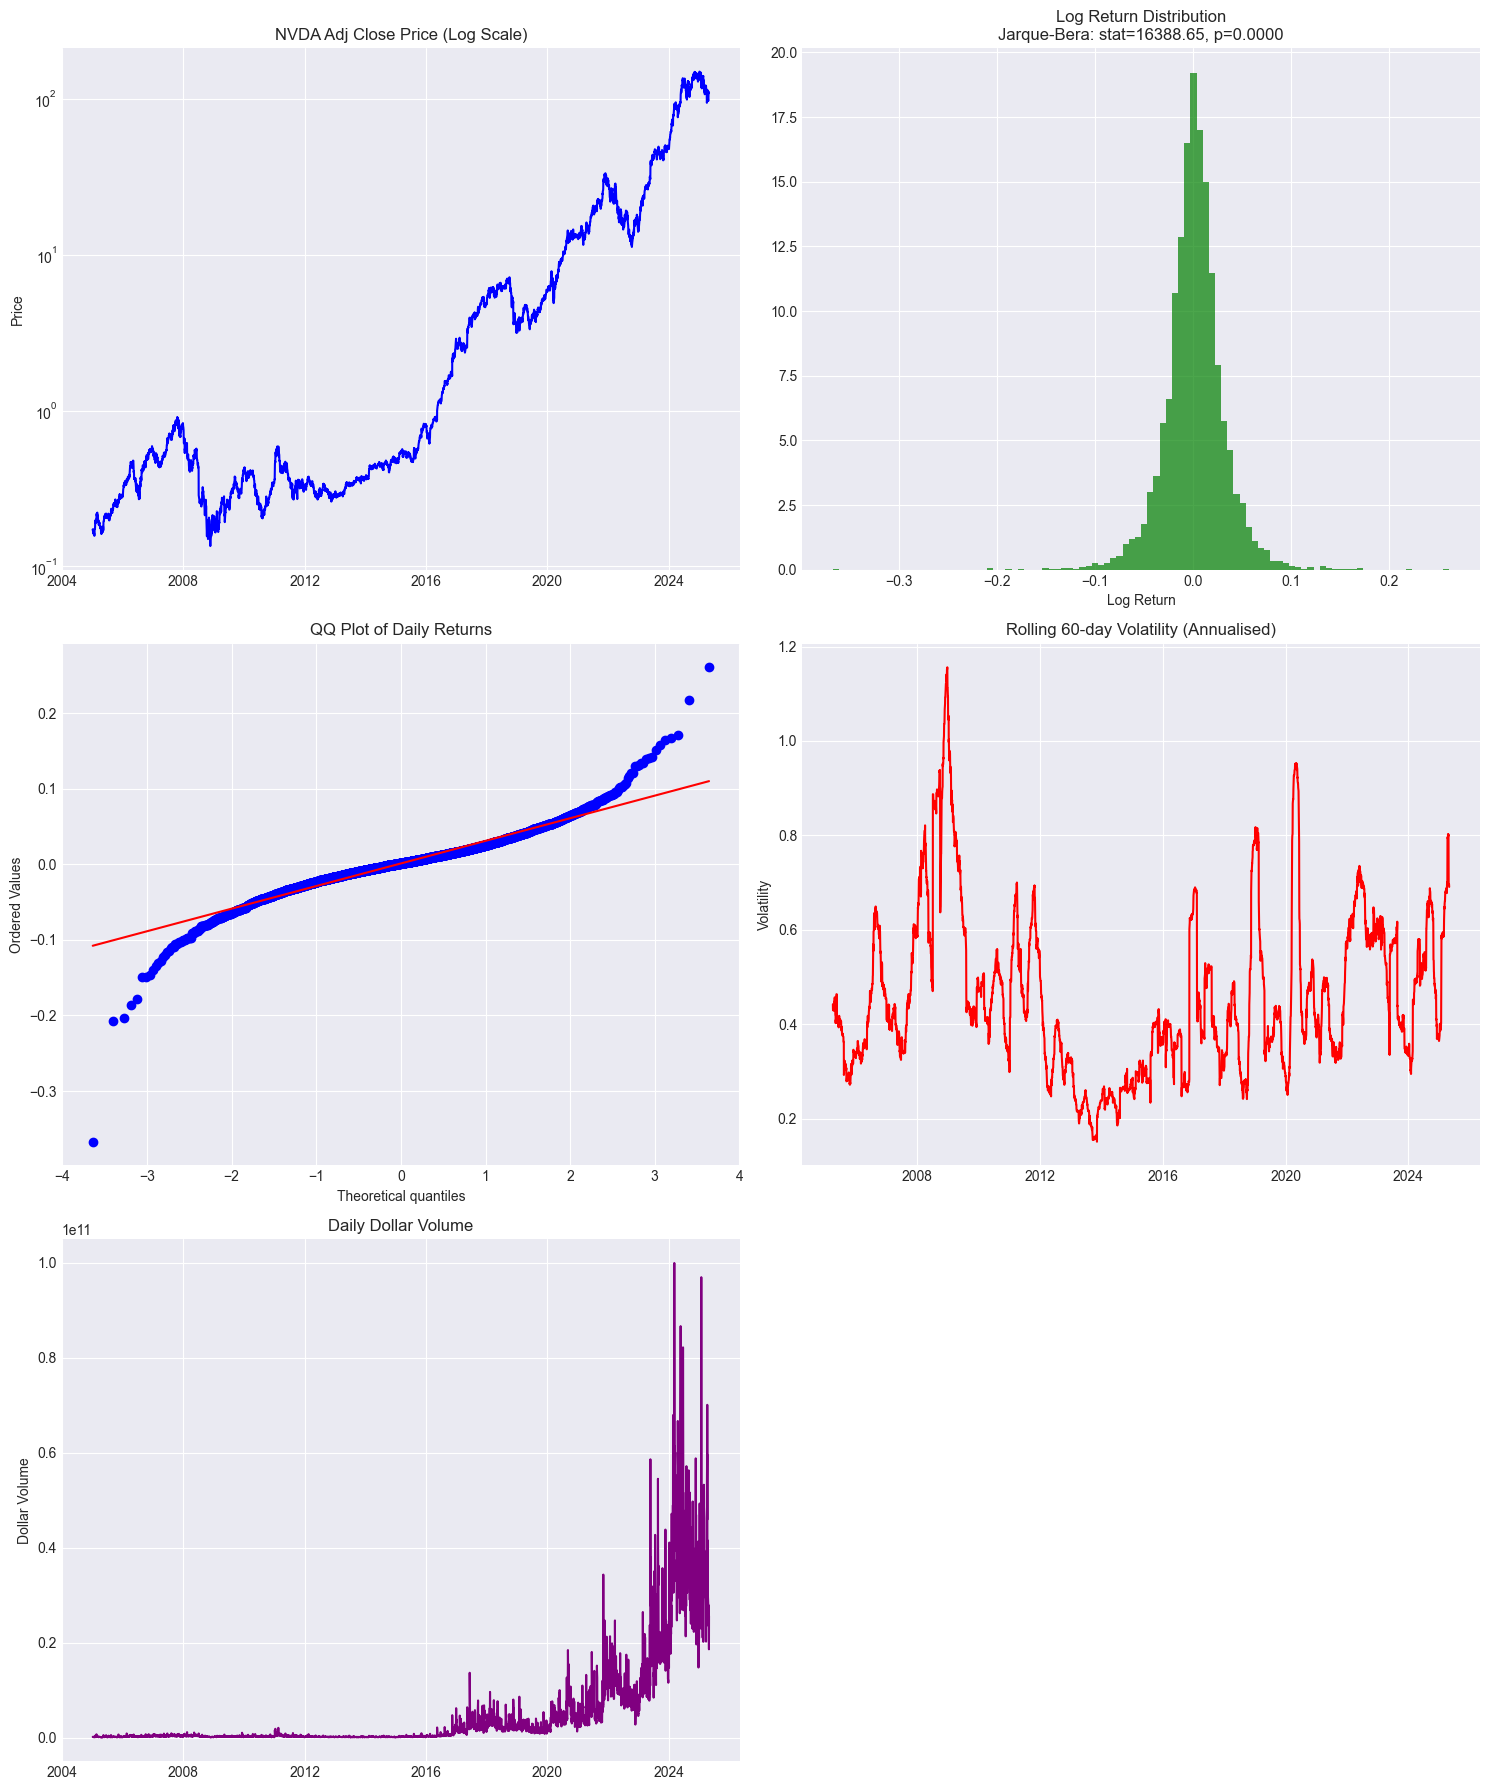

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# a. NVDA Adj Close price chart (log scale)
axes[0, 0].plot(df.index, df['Adj Close'], color='blue')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('NVDA Adj Close Price (Log Scale)')
axes[0, 0].set_ylabel('Price')

# b. Daily log return distribution with Jarque-Bera
jb_stat, jb_p = stats.jarque_bera(df['log_return'])
axes[0, 1].hist(df['log_return'], bins=100, alpha=0.7, color='green', density=True)
axes[0, 1].set_title(f'Log Return Distribution\nJarque-Bera: stat={jb_stat:.2f}, p={jb_p:.4f}')
axes[0, 1].set_xlabel('Log Return')

# c. QQ plot
stats.probplot(df['log_return'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ Plot of Daily Returns')

# d. Rolling 60-day volatility (annualised)
roll_vol = df['log_return'].rolling(window=60).std() * np.sqrt(252)
axes[1, 1].plot(df.index, roll_vol, color='red')
axes[1, 1].set_title('Rolling 60-day Volatility (Annualised)')
axes[1, 1].set_ylabel('Volatility')

# e. Dollar volume time series
axes[2, 0].plot(df.index, df['dollar_volume'], color='purple')
axes[2, 0].set_title('Daily Dollar Volume')
axes[2, 0].set_ylabel('Dollar Volume')

axes[2, 1].axis('off') # Hide unused subplot
plt.tight_layout()
plt.show()


## 6. Save Cleaned Data


In [7]:
df.to_parquet('../data/processed/nvda_clean.parquet')
print("Saved cleaned DataFrame to data/processed/nvda_clean.parquet")


Saved cleaned DataFrame to data/processed/nvda_clean.parquet
